In [224]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import pandas as pd
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import *
from laboneq.analysis.fitting import oscillatory
from laboneq.analysis.fitting import oscillatory_decay

print(laboneq.__version__)

2.51.0


In [225]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.09.20 02:27:28.007] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.09.20 02:27:28.021] INFO    VERSION: laboneq 2.51.0
[2025.09.20 02:27:28.023] INFO    Connecting to data server at 127.0.0.1:8004
[2025.09.20 02:27:28.026] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.09.20 02:27:28.032] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.09.20 02:27:28.037] INFO    Configuring the device setup
[2025.09.20 02:27:28.044] INFO    The device setup is configured


In [226]:
res_lo_freq = 7e9
qb_lo_freq = 5.2e9
qubit_label = "Q2"  # change if needed
# qb_freq = 3.10268e9 #Q1
qb_freq = 5.147950e9 #Q2
# qb_freq = 3.19190e9 #Q3
# qb_freq = 3.37406e9 #Q4
# qb_freq =3.37316e9 #Q5
# qb_freq = 3.3990e9 #Q6

# res_freq = 6.77788288e9 #Q1
res_freq = 6.80982122e9 #Q2
# res_freq = 7.20643e9 #Q3
# res_freq = 7.23027e9 #Q4
# res_freq = 7.26203e9 #Q5
# res_freq = 7.29047e9 #Q6
rlx_time = 50e-6

delay_start = 1e-8
delay_stop = 5e-6
delay_num = 51


# drive_pulse_amp = 0.562 #Q1
drive_pulse_amp = 0.449 #Q2
# drive_pulse_amp = 0.199 #Q3
# drive_pulse_amp = 0.184 #Q4
# drive_pulse_amp = 0.263 #Q5
# drive_pulse_amp =  0.188#Q6

# drive_pulse_length = 0.92e-6 # Q1
drive_pulse_length = 2.716e-6 # Q2
# drive_pulse_length = 1.044e-6 # Q3
# drive_pulse_length = 0.974e-6 # Q4
# drive_pulse_length = 0.979e-6 # Q5
# drive_pulse_length =  1.034e-6# Q6

drive_range = -5
# drive_range = 0
num_averages = 13  # average number = 2^n, n_max = 17
measure_range = -30  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.2
measure_pulse_length = 5e-6
acquire_range = -45

In [227]:
wait_length_swp = LinearSweepParameter(uid="wait_length_sweep", start=delay_start, stop=delay_stop, count=delay_num)

In [228]:
def spin_echo():

    # Create Experiment
    exp = Experiment(
        uid = "spin_echo_shots",
        signals = [
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )
    readout_pulse = pulse_library.const(uid="readout_pulse", length=measure_pulse_length, amplitude=measure_amp)
    x90_pulse = pulse_library.const(uid="drive", length=(drive_pulse_length/2), amplitude=drive_pulse_amp, can_compress = True)
    # x180_pulse = pulse_library.const(uid="drive180", length=drive_pulse_length, amplitude=drive_pulse_amp, can_compress=False)

    with exp.acquire_loop_rt(
        uid="shots",
        count=pow(2, num_averages),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        with exp.sweep(uid="wait_swep", parameter = wait_length_swp):
            with exp.section(uid="echo_seq"):
                exp.play(signal="drive", pulse=x90_pulse)
                exp.delay(signal="drive", time=wait_length_swp)      # τ
                exp.play(signal="drive", pulse=x90_pulse)
                exp.play(signal="drive", pulse=x90_pulse)
                exp.delay(signal="drive", time=wait_length_swp)      # τ
                exp.play(signal="drive", pulse=x90_pulse)             # final π/2

                
            with exp.section(uid="readout", play_after="echo_seq"):
                exp.measure(
                    measure_signal='measure',
                    measure_pulse=readout_pulse,
                    acquire_signal="acquire",
                    integration_length = measure_pulse_length,
                    handle="echo",
                    reset_delay = 50e-6,
                )

            with exp.section(uid="relax", length=rlx_time,play_after="readout"):
                # exp.play(signal="twpa_pump", pulse=cw_pump_pulse, amplitude=pump_amp_sweep, length=10e-6)
                exp.reserve("measure")
                exp.reserve("acquire")

    return exp

In [229]:
#  signal map for qubit
def signal_map_default():
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map

echo_exp = spin_echo()
echo_exp.set_signal_map(signal_map_default())

In [230]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq -qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
echo_exp.set_calibration(exp_calibration)

In [231]:
# compile the experiment on the open instrument session
compiled_echo = session.compile(echo_exp)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Echo", compiled_echo)

[2025.09.20 02:27:28.108] INFO    Starting LabOne Q Compiler run...
[2025.09.20 02:27:28.130] INFO    Schedule completed. [0.019 s]
[2025.09.20 02:27:28.798] INFO    Code generation completed for all AWGs. [0.668 s]
[2025.09.20 02:27:28.798] INFO    Completed compilation step 1 of 1. [0.689 s]
[2025.09.20 02:27:28.805] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.09.20 02:27:28.806] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.09.20 02:27:28.807] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.09.20 02:27:28.808] INFO      device_shfqc        0        209            0           1     20000  
[2025.09.20 02:27:28.809] INFO      device_shfqc_sg     1        795           36          35      3200  
[2025.09.20 02:27:28.809] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.09.20 02:27:28.809] INFO      TOTAL                       1004 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Echo_2025-09-20-02-27-28.html

In [232]:
#plot_simulation(compiled_echo, start_time=300e-6, length=20e-6)

In [233]:
# run the compiled experiemnt
echo_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")

# --- Make output folder + timestamp ---
outdir = "Spin_echo(T2)_results"
os.makedirs(outdir, exist_ok=True)

[2025.09.20 02:27:29.825] INFO    Starting near-time execution...
[2025.09.20 02:27:29.892] INFO    Estimated RT execution time: 48.23 s.
[2025.09.20 02:28:18.193] INFO    Finished near-time execution.


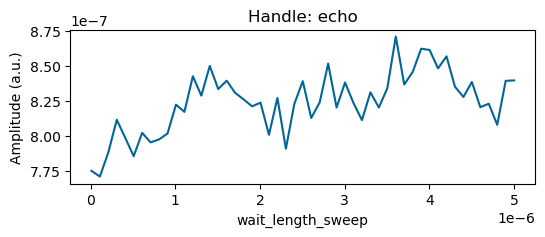

In [234]:
plot_results(echo_results)

In [235]:
# Pull Spin echo data
echo_res   = echo_results.get_data("echo")      # complex data (IQ)
echo_delay = echo_results.get_axis("echo")[0]   # seconds

Saved figure to Spin_echo(T2)_results\T2_Echo_Q2_20250920T022818.png
Saved data to Spin_echo(T2)_results\T2_Echo_Q2_20250920T022818.csv


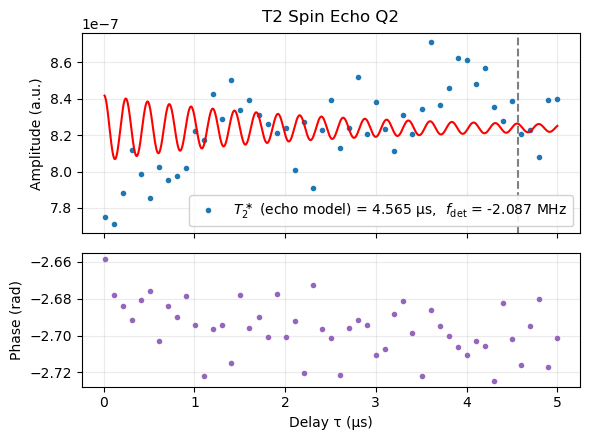

In [236]:
import numpy as np
import os, time
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------
# Pull Spin Echo data
# -----------------------
echo_res   = echo_results.get_data("echo")      # complex IQ
echo_delay = echo_results.get_axis("echo")[0]   # seconds

# -----------------------
# Convert to μs & unpack
# -----------------------
x = 1e6 * np.asarray(echo_delay, float)         # μs  (this is τ, the inter-pulse delay)
I = np.asarray(np.real(echo_res), float)
Q = np.asarray(np.imag(echo_res), float)
mag = np.abs(echo_res).astype(float)
phase_rad = np.angle(echo_res)

# -----------------------
# Clean + sort
# -----------------------
m = np.isfinite(x) & np.isfinite(I) & np.isfinite(Q) & np.isfinite(mag) & np.isfinite(phase_rad)
x, I, Q, mag, phase_rad = x[m], I[m], Q[m], mag[m], phase_rad[m]
idx = np.argsort(x)
x, I, Q, mag, phase_rad = x[idx], I[idx], Q[idx], mag[idx], phase_rad[idx]

if x.size < 3:
    raise RuntimeError("Spin Echo: not enough valid points to fit.")

# ---------- Model (Ramsey-style, but for Echo vs τ) ----------
# For spin echo, the total free-evolution time is 2*τ.
# Use the provided Ramsey model form, substituting t_us -> 2*τ.
def T2_ramsey_model(t_us, A, T2star_us, fdet_MHz, phi, C):
    return A * np.exp(-t_us / T2star_us) * np.cos(2.0*np.pi * fdet_MHz * t_us + phi) + C

def T2_echo_model_ramsey_tau(tau_us, A, T2star_us, fdet_MHz, phi, C):
    # Map τ -> effective Ramsey-time t = 2τ
    t_eff = 2.0 * np.maximum(tau_us, 0.0)
    T2star_us = np.maximum(T2star_us, 1e-9)
    return T2_ramsey_model(t_eff, A, T2star_us, fdet_MHz, phi, C)

# Initial guesses (from magnitude)
A_guess   = 0.5 * (np.nanmax(mag) - np.nanmin(mag))
C_guess   = float(np.nanmedian(mag))
# T2* guess w.r.t. effective time (2τ): use a scale similar to median(2τ)
T2star_guess = max(2.0*np.median(x), 1e-3)   # μs; avoid zero
fdet_guess_MHz = 0.0
phi_guess = 0.0

p0 = [max(A_guess, 1e-9), T2star_guess, fdet_guess_MHz, phi_guess, C_guess]
bounds = (
    [0.0,     1e-6,    -np.inf,     -2.0*np.pi,  -np.inf],   # lower
    [np.inf,  np.inf,   np.inf,       2.0*np.pi,   np.inf],   # upper
)

# -----------------------
# Fit ON MAGNITUDE (linear a.u.)
# -----------------------
popt, pcov = curve_fit(
    T2_echo_model_ramsey_tau, x, mag,
    p0=p0, bounds=bounds, maxfev=20000
)
A_fit, T2_echo_fit_us, fdet_fit_MHz, phi_fit, C_fit = popt

# Smooth curve for display
xf = np.linspace(x.min(), x.max(), 1200)
y_fit = T2_echo_model_ramsey_tau(xf, *popt)

# -----------------------
# Plot: magnitude (top) + unwrapped phase (bottom)
# -----------------------
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True,
                        gridspec_kw={'height_ratios': [1.5, 1.0]})

# Top: magnitude + fit
axs[0].plot(x, mag, 'o', ms=3, label="|IQ| (a.u.)")
axs[0].plot(xf, y_fit, '-r', lw=1.5, label="fit on |IQ|")
axs[0].axvline(T2_echo_fit_us, color="grey", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Amplitude (a.u.)")
axs[0].legend(
    [rf"$T_2^\ast$ (echo model) = {T2_echo_fit_us:.3f} μs,  $f_{{\rm det}}$ = {fdet_fit_MHz:.3f} MHz"],
    loc="lower right", framealpha=0.9
)

# Title
qubit_label = globals().get("qubit_label", "Q?")
axs[0].set_title(f"T2 Spin Echo {qubit_label}", fontsize=12, pad=8)
axs[0].grid(True, alpha=0.25)

# Bottom: phase (unwrapped) vs time
phase_unw = np.unwrap(phase_rad)
axs[1].plot(x, phase_unw, 'o', ms=3, color="tab:purple")
axs[1].set_xlabel("Delay τ (μs)")
axs[1].set_ylabel("Phase (rad)")
axs[1].grid(True, alpha=0.25)

plt.tight_layout()

# -----------------------
# Save figure & CSV
# -----------------------
outdir = globals().get("outdir", "echo_results")
os.makedirs(outdir, exist_ok=True)
timestamp = globals().get("timestamp", time.strftime("%Y%m%dT%H%M%S"))

fig_path = os.path.join(outdir, f"T2_Echo_{qubit_label}_{timestamp}.png")
plt.savefig(fig_path, dpi=600)
print(f"Saved figure to {fig_path}")

df = pd.DataFrame({
    "Delay_us": x,                         # τ (μs)
    "I": I,
    "Q": Q,
    "Magnitude_linear": mag,
    "Phase_rad": phase_rad,
    "Fit_on_data": T2_echo_model_ramsey_tau(x, *popt),
    "A_fit": np.full_like(x, A_fit, dtype=float),
    "T2_echo_fit_us": np.full_like(x, T2_echo_fit_us, dtype=float),
    "fdet_fit_MHz": np.full_like(x, fdet_fit_MHz, dtype=float),
    "phi_fit": np.full_like(x, phi_fit, dtype=float),
    "C_fit": np.full_like(x, C_fit, dtype=float),
})

csv_path = os.path.join(outdir, f"T2_Echo_{qubit_label}_{timestamp}.csv")
df.to_csv(csv_path, index=False)
print(f"Saved data to {csv_path}")

plt.show()
